In [1]:
import sys
import subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 
                'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn'])
print("Done!")

Done!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
print("All imports done!")

All imports done!


In [3]:
df = pd.read_csv('city_temperature.csv')
print(df.shape)
df.head()

(2906327, 8)


,Region,Country,State,City,Month,Day,Year,AvgTemperature
0,Africa,Algeria,NaN,Algiers,1,1,1995,64.2
1,Africa,Algeria,NaN,Algiers,1,2,1995,49.4
2,Africa,Algeria,NaN,Algiers,1,3,1995,48.8
3,Africa,Algeria,NaN,Algiers,1,4,1995,46.4
4,Africa,Algeria,NaN,Algiers,1,5,1995,47.9


In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)

Shape: (2906327, 8)

Columns: ['Region', 'Country', 'State', 'City', 'Month', 'Day', 'Year', 'AvgTemperature']

Data Types:
 Region                str
Country               str
State                 str
City                  str
Month               int64
Day                 int64
Year                int64
AvgTemperature    float64
dtype: object


In [5]:
print("Missing Values:\n", df.isnull().sum())
df.describe()

Missing Values:
 Region                  0
Country                 0
State             1450990
City                    0
Month                   0
Day                     0
Year                    0
AvgTemperature          0
dtype: int64


,Month,Day,Year,AvgTemperature
count,2.906327e+06,2.906327e+06,2.906327e+06,2.906327e+06
mean,6.469163e+00,1.571682e+01,2.006624e+03,5.600492e+01
std,3.456489e+00,8.800534e+00,2.338226e+01,3.212359e+01
min,1.000000e+00,0.000000e+00,2.000000e+02,-9.900000e+01
25%,3.000000e+00,8.000000e+00,2.001000e+03,4.580000e+01
50%,6.000000e+00,1.600000e+01,2.007000e+03,6.250000e+01
75%,9.000000e+00,2.300000e+01,2.013000e+03,7.550000e+01
max,1.200000e+01,3.100000e+01,2.020000e+03,1.100000e+02


In [6]:
print("Regions:", df['Region'].unique())
print("Total Countries:", df['Country'].nunique())
print("Total Cities:", df['City'].nunique())
print("Year Range:", df['Year'].min(), "to", df['Year'].max())

Regions: <StringArray>
[                           'Africa',                              'Asia',
           'Australia/South Pacific',                            'Europe',
                       'Middle East',                     'North America',
 'South/Central America & Carribean']
Length: 7, dtype: str
Total Countries: 125
Total Cities: 321
Year Range: 200 to 2020


In [7]:
region_stats = df.groupby('Region')['AvgTemperature'].agg(['mean','std','min','max'])
region_stats.columns = ['Mean Temp', 'Std Dev', 'Min Temp', 'Max Temp']
print(region_stats)

                                   Mean Temp    Std Dev  Min Temp  Max Temp
Region                                                                     
Africa                             53.549517  57.068235     -99.0     102.8
Asia                               62.568652  35.655674     -99.0     103.7
Australia/South Pacific            61.180869  16.540594     -99.0      96.8
Europe                             46.696285  31.425646     -99.0     102.5
Middle East                        68.384554  34.446461     -99.0     110.0
North America                      55.300933  22.411278     -99.0     107.7
South/Central America & Carribean  62.189439  41.513250     -99.0      97.4


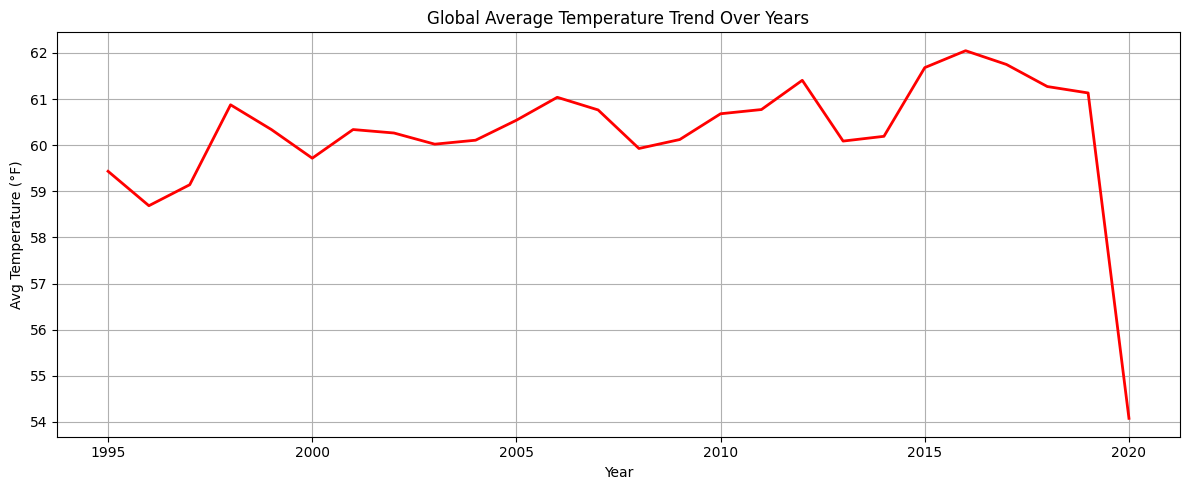

Observation: A gradual upward trend is visible, consistent with global warming.


In [24]:
yearly_avg = df.groupby('Year')['AvgTemperature'].mean()
plt.figure(figsize=(12,5))
plt.plot(yearly_avg.index, yearly_avg.values, color='red', linewidth=2)
plt.title('Global Average Temperature Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Avg Temperature (°F)')
plt.grid(True)
plt.tight_layout()
plt.show()
print("Observation: A gradual upward trend is visible, consistent with global warming.")

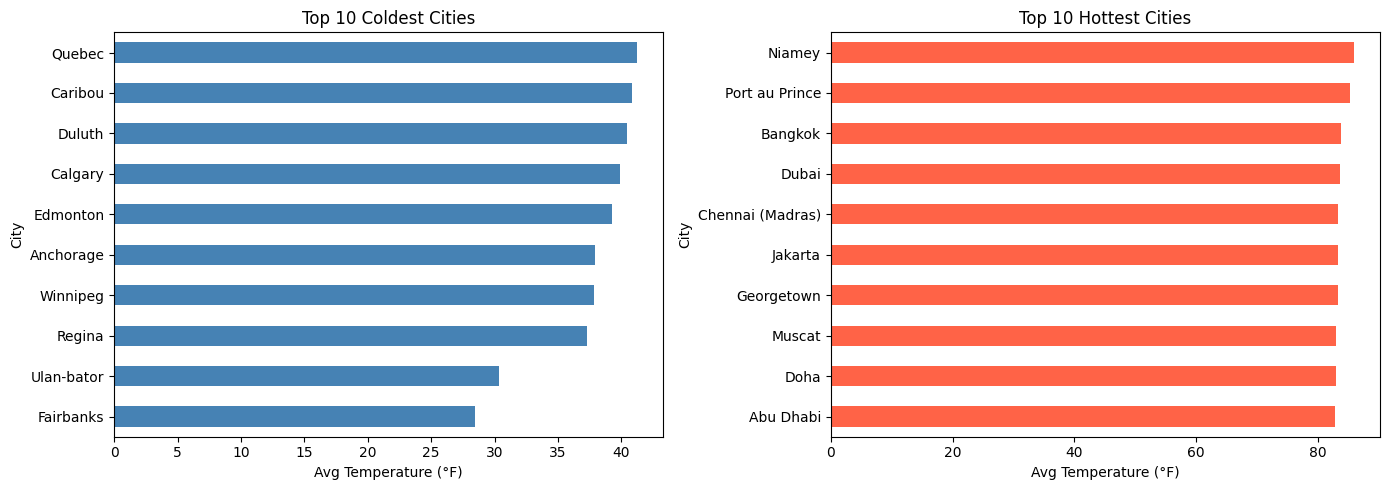

In [25]:
city_avg = df.groupby('City')['AvgTemperature'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

city_avg.head(10).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Coldest Cities')
axes[0].set_xlabel('Avg Temperature (°F)')

city_avg.tail(10).plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Top 10 Hottest Cities')
axes[1].set_xlabel('Avg Temperature (°F)')

plt.tight_layout()
plt.show()

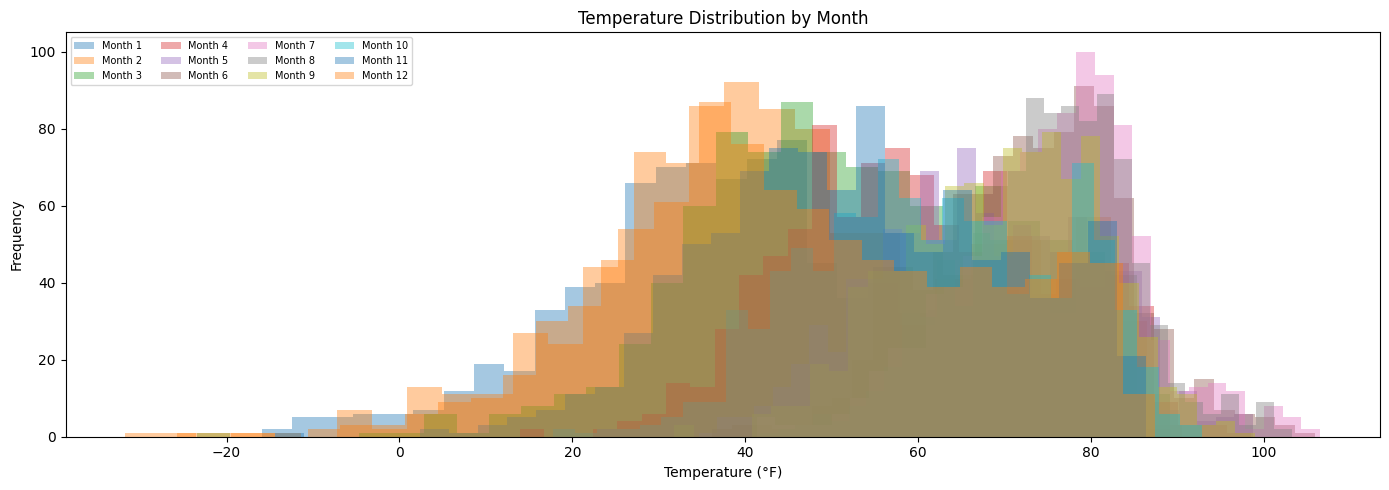

Observation: Summer months (6-8) show higher temperatures, winter months (12-2) are lower.


In [26]:
plt.figure(figsize=(14,5))
for month in range(1, 13):
    subset = df[df['Month'] == month]['AvgTemperature']
    plt.hist(subset.sample(min(1000, len(subset))), bins=30, alpha=0.4, label=f'Month {month}')
plt.title('Temperature Distribution by Month')
plt.xlabel('Temperature (°F)')
plt.ylabel('Frequency')
plt.legend(ncol=4, fontsize=7)
plt.tight_layout()
plt.show()
print("Observation: Summer months (6-8) show higher temperatures, winter months (12-2) are lower.")

In [8]:
print("Before cleaning:", df.shape)
df = df[df['AvgTemperature'] > -50]
print("After removing invalid temps:", df.shape)

df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

df['AvgTemp_C'] = (df['AvgTemperature'] - 32) * 5/9

print("Cleaning done!")

Before cleaning: (2906327, 8)
After removing invalid temps: (2826654, 8)
After removing duplicates: (2806368, 8)
Cleaning done!


In [9]:
le = LabelEncoder()
df['Region_enc']  = le.fit_transform(df['Region'])
df['Country_enc'] = le.fit_transform(df['Country'])
df['City_enc']    = le.fit_transform(df['City'])

print("Encoding done!")
df[['Region','Region_enc','Country','Country_enc']].head()

Encoding done!


,Region,Region_enc,Country,Country_enc
0,Africa,0,Algeria,1
1,Africa,0,Algeria,1
2,Africa,0,Algeria,1
3,Africa,0,Algeria,1
4,Africa,0,Algeria,1


<module 'matplotlib.pyplot' from 'C:\\Users\\BISMILLAH\\AppData\\Local\\Programs\\Python\\Python314\\Lib\\site-packages\\matplotlib\\pyplot.py'>

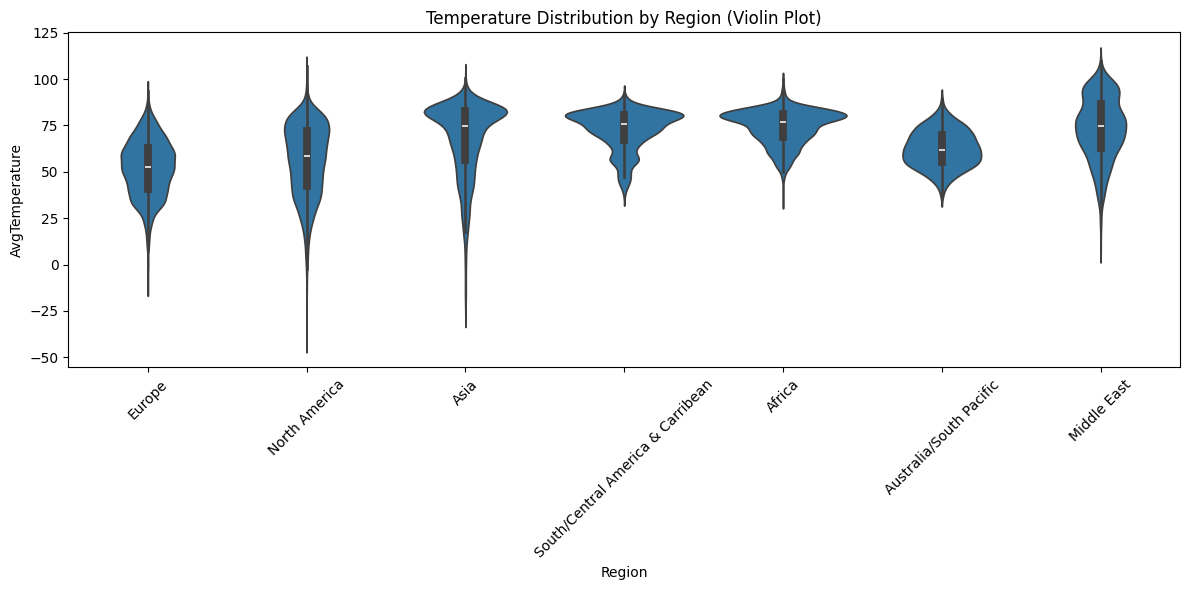

In [11]:
plt.figure(figsize=(12,6))
sns.violinplot(x='Region', y='AvgTemperature', data=df.sample(50000))
plt.title('Temperature Distribution by Region (Violin Plot)')
plt.xticks(rotation=45)
plt.tight_layout()
plt

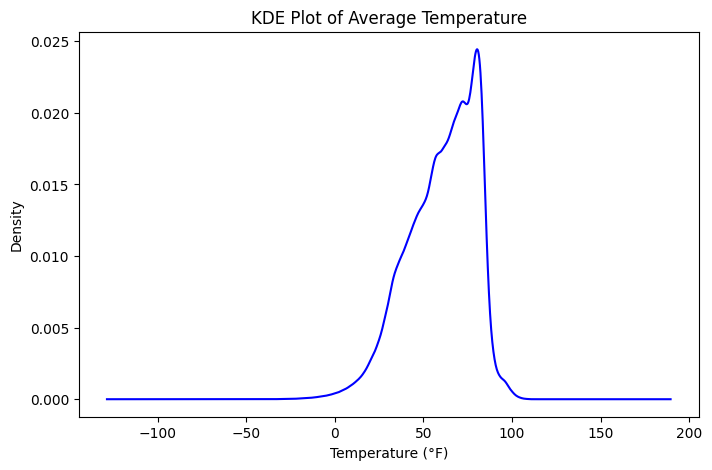

In [12]:
plt.figure(figsize=(8,5))
df['AvgTemperature'].plot.kde(color='blue')
plt.title('KDE Plot of Average Temperature')
plt.xlabel('Temperature (°F)')
plt.show()

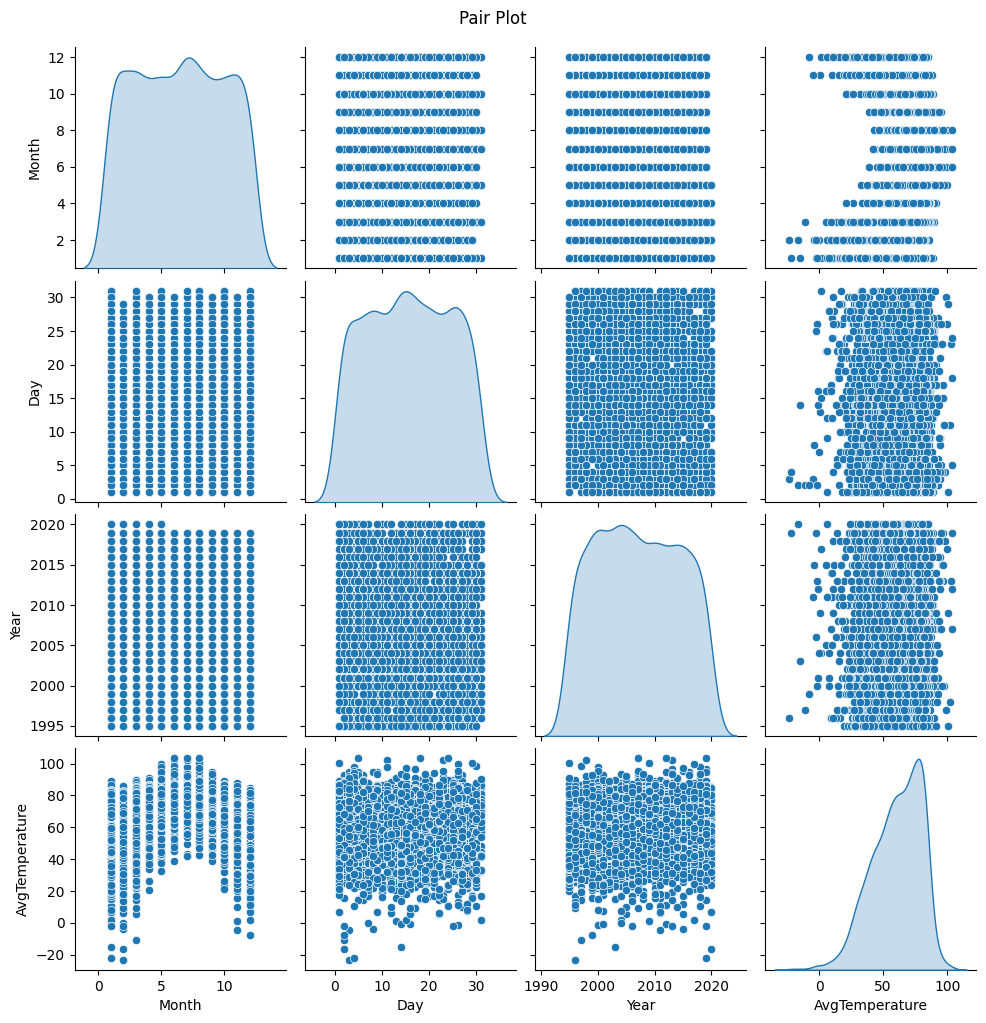

In [13]:
sample = df[['Month','Day','Year','AvgTemperature']].sample(3000)
sns.pairplot(sample, diag_kind='kde')
plt.suptitle('Pair Plot', y=1.02)
plt.show()

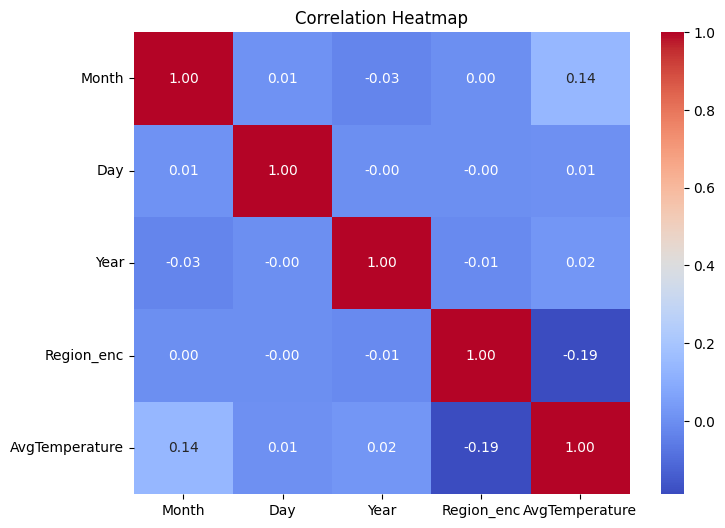

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Month','Day','Year','Region_enc','AvgTemperature']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

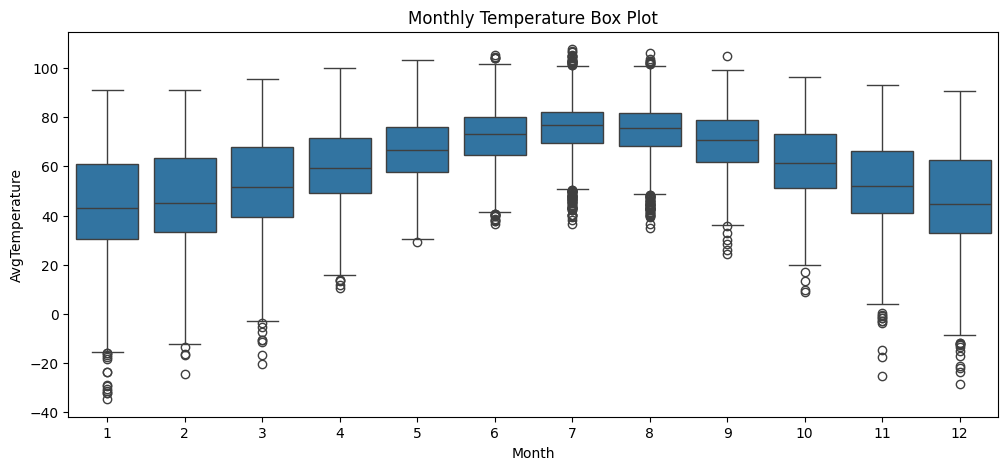

In [15]:
plt.figure(figsize=(12,5))
sns.boxplot(x='Month', y='AvgTemperature', data=df.sample(50000))
plt.title('Monthly Temperature Box Plot')
plt.show()

In [16]:
features = ['Month', 'Day', 'Year', 'Region_enc', 'Country_enc']
X = df[features]
y = df['AvgTemperature']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2806368, 5)
Target shape: (2806368,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (2245094, 5)
Testing size: (561274, 5)


In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained!")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model trained!
Coefficients: [ 2.68825433  0.11400202  0.46098325 -3.22781571 -0.98318474]
Intercept: 60.38877263856402


In [19]:
y_pred = model.predict(X_test)

print("First 5 Actual:   ", list(y_test[:5]))
print("First 5 Predicted:", list(y_pred[:5]))

First 5 Actual:    [79.9, 70.3, 78.0, 68.0, 79.3]
First 5 Predicted: [np.float64(63.16256841566323), np.float64(59.2776428937885), np.float64(58.5010998083022), np.float64(61.95474294792283), np.float64(67.58029858983095)]


In [20]:
mae   = mean_absolute_error(y_test, y_pred)
mse   = mean_squared_error(y_test, y_pred)
rmse  = np.sqrt(mse)
r2    = r2_score(y_test, y_pred)
n     = len(y_test)
p     = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE:      {mae:.4f}")
print(f"MSE:      {mse:.4f}")
print(f"RMSE:     {rmse:.4f}")
print(f"R²:       {r2:.4f}")
print(f"Adj. R²:  {adj_r2:.4f}")

MAE:      15.1373
MSE:      344.1166
RMSE:     18.5504
R²:       0.0578
Adj. R²:  0.0578


In [21]:
results = pd.DataFrame({
    "Model":   ["Linear Regression"],
    "MAE":     [round(mae, 4)],
    "MSE":     [round(mse, 4)],
    "RMSE":    [round(rmse, 4)],
    "R²":      [round(r2, 4)],
    "Adj. R²": [round(adj_r2, 4)]
})
results

,Model,MAE,MSE,RMSE,R²,Adj. R²
0,Linear Regression,15.1373,344.1166,18.5504,0.0578,0.0578


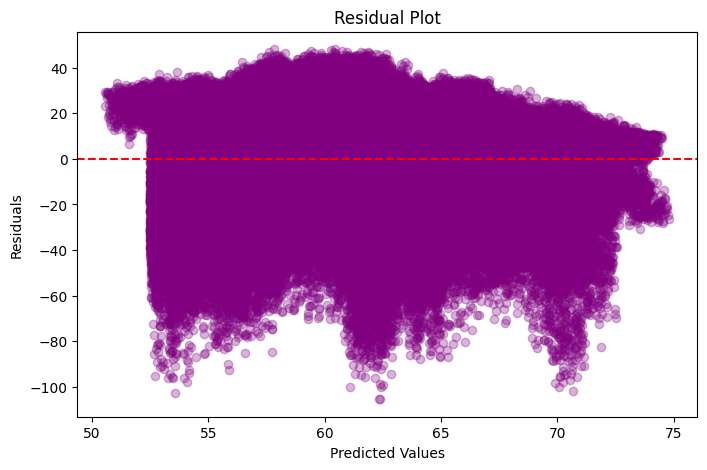

In [22]:
residuals = y_test - y_pred
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.3, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

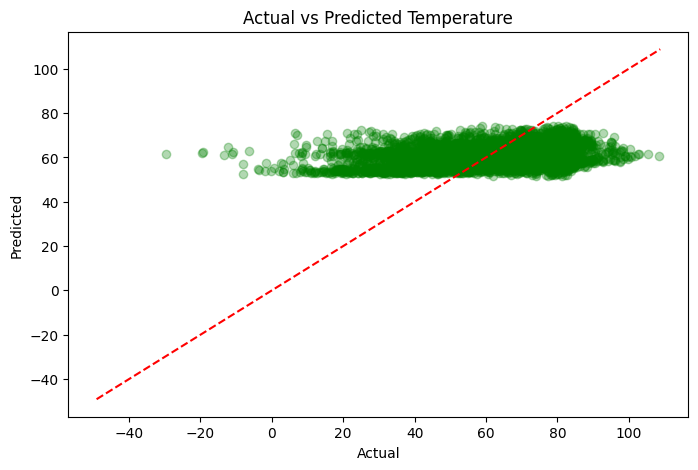

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(y_test[:5000], y_pred[:5000], alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted Temperature')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()